# Spacing Statistics - Oneline

## 1. Importing / Installing Packages

In [1]:
import os # Importing os module for operating system dependent functionality

import glob # Importing glob module for file pattern matching

import pandas as pd # Importing pandas package

# Set the maximum number of columns to display to None
pd.set_option('display.max_columns', None)

import numpy as np # Importing numpy package

from typing import Dict, Tuple, List, Union, Optional, Any, Iterable, Literal # Importing specific types from typing module

from matplotlib import pyplot as plt # Importing pyplot from matplotlib for plotting

# Setting matplotlib to inline mode for Jupyter notebooks
%matplotlib inline 

%config InlineBackend.figure_format = 'svg' # Configuring inline backend to use SVG format for figures

# from src.well_data import WellDataLoader, GeoSurveyProcessor # Importing custom classes for well data management

from __future__ import annotations # Enabling future annotations for type hinting

from src.utils import reorder_columns # Importing utility function to reorder DataFrame columns

## 2. Importing Data to Dataframes

### 2.1 Importing Spacing i-k pairs stat data to dataframe

In [2]:
# Path to your folder
folder_path = r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\Python\Parent_Child_Spacing\notebooks\spacing_batches_MB_2010_v2"

# Get all parquet files in the folder
parquet_files = glob.glob(os.path.join(folder_path, "*.parquet"))

# Read and concatenate them into a single DataFrame
df_spacing_ik = pd.concat([pd.read_parquet(file) for file in parquet_files], ignore_index=True)

In [3]:
df_spacing_ik_filterd = df_spacing_ik[df_spacing_ik['reject_reason']==""].reset_index(drop=True).copy()

In [4]:
df_spacing_ik_filterd = reorder_columns(df=df_spacing_ik_filterd, columns_to_move=['direction_axis', 'direction_to_k_from_i_axis',
       'direction_axis_confidence', 'direction_axis_distribution',
       'axis_forced'], reference_column='drill_direction_k')

### 2.2 Importing Header Data

In [5]:
df_header = pd.read_csv(
    r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\Python\Parent_Child_Spacing\data\MB_Header_2010.csv",
                        dtype={'uwi': str})

df_header.drop(columns=['surface_lat', 'surface_lon'], inplace=True)

### 2.2 Importing UTM Lateral Directional Survey

In [6]:
df_utm_lateral = pd.read_csv(
    r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\MB Investigation\DirectionalSurvey\MB_UTM_Lateral.csv",
    dtype={'uwi': str})

## 3. Define the Class

In [7]:
class DirectionalBenchNeighbors:
    """
    Summarize nearest neighbors per well_i by bench and opposite direction.

    For each well_i, produce:
      - SAME-bench closest (any direction, or axis-limited) -> *_same_1
      - SAME-bench closest in the OPPOSITE direction of same_1 -> *_same_2
      - DIFFERENT-bench closest (any direction, or axis-limited) -> *_near_1
      - DIFFERENT-bench closest in the OPPOSITE direction of near_1 -> *_near_2

    Required columns
    ----------------
    spacing_df:
        'well_i', 'well_k', 'horizontal_dist', 'vertical_dist', '3D_dist',
        'direction_to_k_from_i_axis', 'overlap_pct_k'
        # overlap_pct_k is only required if overlap_pct_k_min is provided.
    header_df:
        'uwi', 'bench'

    Parameters (at call-time)
    -------------------------
    cutoff_ft : float
        Horizontal cutoff distance (feet).
    vertical_cutoff_ft : float, optional
        If provided, also require vertical_dist <= vertical_cutoff_ft.
        If None, no vertical filter is applied.
    axis_mode : {'any', 'EW', 'NS'}, default 'any'
        If 'EW', only E/W directions are eligible for the *_1 pick.
        If 'NS', only N/S directions are eligible for the *_1 pick.
        If 'any', all four directions can compete for *_1.
    prefer_axis : {'EW', 'NS'} | None, default None
        If set and there is a tie in horizontal distance for *_1 across axes,
        prefer the candidate whose direction belongs to that axis family.
    overlap_pct_k_min : float, optional
        If provided, require that overlap_pct_k >= this value for a pair
        to be considered. This ensures that well_k overlaps well_i by at
        least the given percentage of k’s own lateral length.

    Output columns
    --------------
      uwi_same_1,  hz_ft_to_same_1,  vt_ft_to_same_1,  3d_ft_to_same_1,
      uwi_same_2,  hz_ft_to_same_2,  vt_ft_to_same_2,  3d_ft_to_same_2,
      uwi_near_1,  hz_ft_to_near_1,  vt_ft_to_near_1,  3d_ft_to_near_1,
      uwi_near_2,  hz_ft_to_near_2,  vt_ft_to_near_2,  3d_ft_to_near_2

    Examples
    --------
    >>> nb = DirectionalBenchNeighbors()

    # Example 1: horizontal cutoff only
    >>> out1 = nb.summarize(spacing_df, header_df, cutoff_ft=1320.0)
    >>> out1.filter(regex="^uwi_|^hz_ft_").head()

    # Example 2: add vertical cutoff of 200 ft
    >>> out2 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, vertical_cutoff_ft=200.0)

    # Example 3: restrict initial pick to EW directions only
    >>> out3 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, axis_mode="EW")

    # Example 4: allow any axis but prefer NS in case of ties
    >>> out4 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, axis_mode="any", prefer_axis="NS")

    # Example 5: require at least 80% overlap of k relative to i
    >>> out5 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, overlap_pct_k_min=0.80)
    """

    # --- Type aliases inside the class ---
    Direction = Literal["E", "W", "N", "S"]
    AxisMode = Literal["any", "EW", "NS"]
    AxisPref = Literal["EW", "NS"]

    _OPPOSITE: Dict[Direction, Direction] = {"E": "W", "W": "E", "N": "S", "S": "N"}

    def __init__(self, *, tie_break_on: str = "well_k") -> None:
        """
        Parameters
        ----------
        tie_break_on : str, default 'well_k'
            Secondary stable key when distances tie.
        """
        self.tie_break_on = tie_break_on

    # ---------- Public API ----------

    def summarize(
        self,
        spacing_df: pd.DataFrame,
        header_df: pd.DataFrame,
        *,
        cutoff_ft: float,
        vertical_cutoff_ft: Optional[float] = None,
        axis_mode: AxisMode = "any",
        prefer_axis: Optional[AxisPref] = None,
        overlap_pct_k_min: Optional[float] = None,  # <-- NEW
    ) -> pd.DataFrame:
        self._validate_inputs(spacing_df, header_df)
        """Return one summary row per well_i with *_same_{1,2} and *_near_{1,2}.

        See class docstring for details on behavior and examples.

        Raises
        ------
        ValueError
            If required columns are missing or inputs are inconsistent.
        """
        # Normalize IDs to strings
        spacing = spacing_df.copy()
        spacing["well_i"] = spacing["well_i"].astype(str)
        spacing["well_k"] = spacing["well_k"].astype(str)
        header = header_df.copy()
        header["uwi"] = header["uwi"].astype(str)

        # Map benches
        bench_map = header.set_index("uwi")["bench"]
        spacing["bench_i"] = spacing["well_i"].map(bench_map)
        spacing["bench_k"] = spacing["well_k"].map(bench_map)

        # --- Apply cutoffs ---
        mask = spacing["horizontal_dist"] <= cutoff_ft
        if vertical_cutoff_ft is not None:
            mask &= spacing["vertical_dist"] <= vertical_cutoff_ft

        # NEW: optional overlap filter on k
        if overlap_pct_k_min is not None:
            if "overlap_pct_k" not in spacing.columns:
                raise ValueError(
                    "spacing_df missing required column 'overlap_pct_k' when overlap_pct_k_min is provided."
                )
            mask &= spacing["overlap_pct_k"] >= overlap_pct_k_min

        spacing = spacing.loc[mask].copy()

        if spacing.empty:
            wells = spacing_df["well_i"].astype(str).unique()
            return self._empty_summary(wells)

        # SAME vs NEAR
        spacing["is_same"] = spacing["bench_i"] == spacing["bench_k"]
        same = spacing.loc[spacing["is_same"]].copy()
        near = spacing.loc[~spacing["is_same"]].copy()

        same_summary = self._compute_category_summary(
            same, category="same", axis_mode=axis_mode, prefer_axis=prefer_axis
        )
        near_summary = self._compute_category_summary(
            near, category="near", axis_mode=axis_mode, prefer_axis=prefer_axis
        )

        all_wells = spacing_df["well_i"].astype(str).drop_duplicates().to_frame(name="well_i")
        out = (
            all_wells.merge(same_summary, on="well_i", how="left")
                     .merge(near_summary, on="well_i", how="left")
        )

        ordered_cols = (
            ["well_i"]
            + self._category_cols("same", 1)
            + self._category_cols("same", 2)
            + self._category_cols("near", 1)
            + self._category_cols("near", 2)
        )
        existing_cols = [c for c in ordered_cols if c in out.columns]
        return out[existing_cols + [c for c in out.columns if c not in existing_cols]]
    
    # ---------- Internals: category computation ----------

    def _compute_category_summary(
        self,
        df: pd.DataFrame,
        *,
        category: Literal["same", "near"],
        axis_mode: AxisMode,
        prefer_axis: Optional[AxisPref],
    ) -> pd.DataFrame:
        """
        Build a summary for one category (same/near) using vectorized reductions.

          1) Best-per-direction (well_i, direction) by horizontal_dist
             (tie-break: well_k for determinism).
          2) *_1: among eligible directions (based on axis_mode), pick best overall.
             If `prefer_axis` is set, bias ties toward that axis family.
          3) *_2: pick best entry in the opposite direction of *_1 (if exists).

        Returns
        -------
        pd.DataFrame with:
          ['well_i'] + uwi_{cat}_1, hz_ft_to_{cat}_1, vt_ft_to_{cat}_1, 3d_ft_to_{cat}_1,
                       uwi_{cat}_2, hz_ft_to_{cat}_2, vt_ft_to_{cat}_2, 3d_ft_to_{cat}_2
        """
        if df.empty:
            return pd.DataFrame(columns=["well_i"] + self._category_cols(category, 1) + self._category_cols(category, 2))

        # Step 1: best per-direction (argmin via sort + drop_duplicates)
        per_dir = (
            df.assign(direction=df["direction_to_k_from_i_axis"])
              .sort_values(["well_i", "direction", "horizontal_dist", self.tie_break_on])
              .drop_duplicates(subset=["well_i", "direction"], keep="first")
              .loc[:, ["well_i", "direction", "well_k", "horizontal_dist", "vertical_dist", "3D_dist"]]
        )

        if per_dir.empty:
            return pd.DataFrame(columns=["well_i"] + self._category_cols(category, 1) + self._category_cols(category, 2))

        # Eligible directions for *_1 based on axis_mode
        if axis_mode == "EW":
            eligible = {"E", "W"}
        elif axis_mode == "NS":
            eligible = {"N", "S"}
        else:
            eligible = {"E", "W", "N", "S"}

        per_dir_eligible = per_dir.loc[per_dir["direction"].isin(eligible)].copy()
        if per_dir_eligible.empty:
            # No eligible directions for *_1 => no *_1 and consequently no *_2
            return pd.DataFrame({"well_i": per_dir["well_i"].unique()}).astype({"well_i": str})

        # Step 2: choose *_1 across eligible directions with optional axis preference
        if prefer_axis is None:
            # Pure distance, then well_k
            best_overall = (
                per_dir_eligible.sort_values(["well_i", "horizontal_dist", "well_k"])
                                .drop_duplicates(subset=["well_i"], keep="first")
            )
        else:
            prefer_set = {"E", "W"} if prefer_axis == "EW" else {"N", "S"}
            # Priority 0 if in preferred axis family; 1 otherwise
            per_dir_eligible = per_dir_eligible.assign(
                _axis_priority=np.where(per_dir_eligible["direction"].isin(prefer_set), 0, 1)
            )
            best_overall = (
                per_dir_eligible.sort_values(["well_i", "horizontal_dist", "_axis_priority", "well_k"])
                                .drop_duplicates(subset=["well_i"], keep="first")
            )

        best_overall = best_overall.rename(columns={
            "well_k": f"uwi_{category}_1",
            "horizontal_dist": f"hz_ft_to_{category}_1",
            "vertical_dist": f"vt_ft_to_{category}_1",
            "3D_dist": f"3d_ft_to_{category}_1",
            "direction": f"direction_{category}_1",
        })

        keep_cols_1 = ["well_i",
                       f"uwi_{category}_1",
                       f"hz_ft_to_{category}_1",
                       f"vt_ft_to_{category}_1",
                       f"3d_ft_to_{category}_1",
                       f"direction_{category}_1"]
        best_overall = best_overall.loc[:, keep_cols_1]

        if best_overall.empty:
            return best_overall.drop(columns=[f"direction_{category}_1"], errors="ignore")

        # Step 3: *_2 is best in the opposite direction of *_1 (if present)
        best_overall = best_overall.copy()
        best_overall[f"opp_dir_{category}"] = best_overall[f"direction_{category}_1"].map(self._OPPOSITE)

        # Build lookup for opposite-direction minima (from all per_dir, not just eligible)
        per_dir_for_merge = per_dir.rename(columns={
            "direction": f"opp_dir_{category}",
            "well_k": f"uwi_{category}_2",
            "horizontal_dist": f"hz_ft_to_{category}_2",
            "vertical_dist": f"vt_ft_to_{category}_2",
            "3D_dist": f"3d_ft_to_{category}_2",
        })

        merged = best_overall.merge(
            per_dir_for_merge[["well_i",
                               f"opp_dir_{category}",
                               f"uwi_{category}_2",
                               f"hz_ft_to_{category}_2",
                               f"vt_ft_to_{category}_2",
                               f"3d_ft_to_{category}_2"]],
            on=["well_i", f"opp_dir_{category}"],
            how="left",
        )

        return merged.drop(columns=[f"direction_{category}_1", f"opp_dir_{category}"])

    # ---------- Internals: utilities ----------

    @staticmethod
    def _category_cols(cat: Literal["same", "near"], idx: Literal[1, 2]) -> List[str]:
        return [
            f"uwi_{cat}_{idx}",
            f"hz_ft_to_{cat}_{idx}",
            f"vt_ft_to_{cat}_{idx}",
            f"3d_ft_to_{cat}_{idx}",
        ]

    @staticmethod
    def _empty_summary(wells: Iterable[str]) -> pd.DataFrame:
        cols = ["well_i"]
        for cat in ("same", "near"):
            for idx in (1, 2):
                cols += [
                    f"uwi_{cat}_{idx}",
                    f"hz_ft_to_{cat}_{idx}",
                    f"vt_ft_to_{cat}_{idx}",
                    f"3d_ft_to_{cat}_{idx}",
                ]
        out = pd.DataFrame({"well_i": list(map(str, wells))})
        for c in cols:
            if c != "well_i":
                out[c] = np.nan
        return out

    @staticmethod
    def _validate_inputs(spacing_df: pd.DataFrame, header_df: pd.DataFrame) -> None:
        spacing_required = {
            "well_i",
            "well_k",
            "horizontal_dist",
            "vertical_dist",
            "3D_dist",
            "direction_to_k_from_i_axis",
        }
        header_required = {"uwi", "bench"}

        missing_s = spacing_required - set(spacing_df.columns)
        missing_h = header_required - set(header_df.columns)
        if missing_s:
            raise ValueError(f"spacing_df missing required columns: {sorted(missing_s)}")
        if missing_h:
            raise ValueError(f"header_df missing required columns: {sorted(missing_h)}")

## 3. Testing

In [8]:
def debug_pair_spacing(
    df: pd.DataFrame,
    uwi_i: Union[str, int],
    uwi_k: Union[str, int],
    *,
    step_ft: int = 100,
    use_pca_axis: bool = True,
    theta_parallel_deg: float = 25.0,
    theta_perp_deg: float = 65.0,
    arrow_stride: int = 5,
    save_dir: Optional[Union[str, os.PathLike]] = None,
    figure_prefix: str = "spacing",
    show: bool = True,
) -> Dict[str, Any]:
    # ---------- checks ----------
    for col in ("uwi", "md", "x", "y"):
        if col not in df.columns:
            raise ValueError(f"df must contain column '{col}'")
    has_ll = ("latitude" in df.columns) and ("longitude" in df.columns)

    geod = None
    if has_ll:
        try:
            from pyproj import Geod
            geod = Geod(ellps="WGS84")
        except Exception:
            geod = None

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    df_i = df[df["uwi"] == uwi_i].sort_values("md").copy()
    df_k = df[df["uwi"] == uwi_k].sort_values("md").copy()
    if df_i.empty or df_k.empty:
        raise ValueError("One or both UWIs not found in df.")

    # ---------- helpers ----------
    def build_ex_from_df(df_: pd.DataFrame, use_pca: bool) -> np.ndarray:
        XY = df_[["x", "y"]].to_numpy()
        heel, toe = XY[0], XY[-1]
        if use_pca and len(XY) >= 2:
            C = XY - XY.mean(0)
            _, _, Vt = np.linalg.svd(C, full_matrices=False)
            ex_ = Vt[0]
            if np.dot(ex_, toe - heel) < 0:
                ex_ = -ex_
        else:
            v = toe - heel
            ex_ = v / (np.linalg.norm(v) + 1e-12)
        return ex_

    def build_local_frame_from_i(df_i_: pd.DataFrame, use_pca: bool) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        XY = df_i_[["x", "y"]].to_numpy()
        origin_ = XY[0].copy()
        ex_ = build_ex_from_df(df_i_, use_pca)
        ey_ = np.array([-ex_[1], ex_[0]])
        return origin_, ex_, ey_

    def project_xy_to_frame(df_: pd.DataFrame, origin_: np.ndarray, ex_: np.ndarray, ey_: np.ndarray) -> np.ndarray:
        XY = df_[["x", "y"]].to_numpy()
        R = XY - origin_
        return np.column_stack([R @ ex_, R @ ey_])

    def arclength(X: np.ndarray) -> np.ndarray:
        d = np.hypot(np.diff(X[:, 0]), np.diff(X[:, 1]))
        return np.concatenate([[0.0], np.cumsum(d)])

    def interp_by_arclength(X: np.ndarray, s_targets: np.ndarray) -> np.ndarray:
        s = arclength(X)
        keep = np.concatenate([[True], np.diff(s) > 1e-9])
        s, Xc = s[keep], X[keep]
        xi = np.interp(s_targets, s, Xc[:, 0])
        yi = np.interp(s_targets, s, Xc[:, 1])
        return np.column_stack([xi, yi])

    def x_overlap_interval(Xi_: np.ndarray, Xk_: np.ndarray) -> Optional[Tuple[float, float]]:
        xi_min, xi_max = Xi_[:, 0].min(), Xi_[:, 0].max()
        xk_min, xk_max = Xk_[:, 0].min(), Xk_[:, 0].max()
        x_lo_, x_hi_ = max(xi_min, xk_min), min(xi_max, xk_max)
        return (x_lo_, x_hi_) if (x_hi_ > x_lo_) else None

    def clip_by_x_band(X: np.ndarray, band: Tuple[float, float]) -> np.ndarray:
        x_lo_, x_hi_ = band
        x = X[:, 0]
        pts = []
        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]
            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo_ or seg_min > x_hi_:
                continue
            if x_lo_ <= x0 <= x_hi_:
                pts.append(P0)
            for xb in (x_lo_, x_hi_):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts.append(P0 + t * (P1 - P0))
            if j == len(X) - 2 and (x_lo_ <= x1 <= x_hi_):
                pts.append(P1)
        if not pts:
            return np.empty((0, 2))
        P = np.vstack(pts)
        if len(P) > 1:
            dup = np.all(np.isclose(np.diff(P, axis=0), 0.0, atol=1e-9), axis=1)
            keep = np.ones(len(P), dtype=bool); keep[1:] = ~dup
            P = P[keep]
        return P

    def interp_y_of_x(X: np.ndarray, x_targets: np.ndarray) -> np.ndarray:
        x = X[:, 0]; y = X[:, 1]
        order = np.argsort(x)
        xs, ys = x[order], y[order]
        keep = np.concatenate([[True], np.diff(xs) > 1e-9])
        xs, ys = xs[keep], ys[keep]
        if xs.size == 0: return np.zeros_like(x_targets, dtype=float)
        if xs.size == 1: return np.full_like(x_targets, ys[0], dtype=float)
        xq = np.clip(x_targets, xs[0], xs[-1])
        return np.interp(xq, xs, ys)

    def clip_with_latlon_by_x_band(
        X: np.ndarray, lat: np.ndarray, lon: np.ndarray, band: Tuple[float, float]
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        x_lo_, x_hi_ = band
        x = X[:, 0]
        pts_xy, pts_lat, pts_lon = [], [], []
        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]
            lat0, lat1 = lat[j], lat[j + 1]
            lon0, lon1 = lon[j], lon[j + 1]
            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo_ or seg_min > x_hi_:
                continue
            if x_lo_ <= x0 <= x_hi_:
                pts_xy.append(P0); pts_lat.append(lat0); pts_lon.append(lon0)
            for xb in (x_lo_, x_hi_):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts_xy.append(P0 + t * (P1 - P0))
                    pts_lat.append(lat0 + t * (lat1 - lat0))
                    pts_lon.append(lon0 + t * (lon1 - lon0))
            if j == len(X) - 2 and (x_lo_ <= x1 <= x_hi_):
                pts_xy.append(P1); pts_lat.append(lat1); pts_lon.append(lon1)
        if not pts_xy:
            return np.empty((0, 2)), np.empty((0,)), np.empty((0,))
        XYc = np.vstack(pts_xy)
        latc = np.asarray(pts_lat, dtype=float)
        lonc = np.asarray(pts_lon, dtype=float)
        if len(XYc) > 1:
            dup = np.all(np.isclose(np.diff(XYc, axis=0), 0.0, atol=1e-9), axis=1)
            keep = np.ones(len(XYc), dtype=bool); keep[1:] = ~dup
            XYc, latc, lonc = XYc[keep], latc[keep], lonc[keep]
        return XYc, latc, lonc

    def crossline_stats_from_overlap(
        Xi_seg_: np.ndarray, Xk_seg_: np.ndarray, step: int
    ) -> Tuple[float, float, float, float, int, np.ndarray, np.ndarray, np.ndarray]:
        if Xi_seg_.size == 0 or Xk_seg_.size == 0:
            return (np.nan, np.nan, np.nan, np.nan, 0,
                    np.empty((0,)), np.empty((0,)), np.empty((0,)))
        xi_min, xi_max = float(Xi_seg_[:, 0].min()), float(Xi_seg_[:, 0].max())
        xk_min, xk_max = float(Xk_seg_[:, 0].min()), float(Xk_seg_[:, 0].max())
        x_lo_, x_hi_ = max(xi_min, xk_min), min(xi_max, xk_max)
        if not (x_hi_ > x_lo_):
            return (np.nan, np.nan, np.nan, np.nan, 0,
                    np.empty((0,)), np.empty((0,)), np.empty((0,)))
        step = max(int(step), 1)
        N = max(int(np.floor((x_hi_ - x_lo_) / step)) + 1, 2)
        xgrid = np.linspace(x_lo_, x_hi_, N)
        yi = interp_y_of_x(Xi_seg_, xgrid)
        yk = interp_y_of_x(Xk_seg_, xgrid)
        dy = np.abs(yk - yi)
        return float(dy.mean()), float(np.median(dy)), float(np.percentile(dy, 5)), float(np.percentile(dy, 95)), int(N), xgrid, yi, yk

    def local_to_utm(X_local: np.ndarray, origin_: np.ndarray, ex_: np.ndarray, ey_: np.ndarray) -> np.ndarray:
        return origin_[None, :] + X_local[:, [0]] * ex_[None, :] + X_local[:, [1]] * ey_[None, :]

    def bin4_from_geod_az(az_deg_from_north: np.ndarray) -> np.ndarray:
        labels = np.array(["N", "E", "S", "W"], dtype=object)
        a = az_deg_from_north % 360.0
        idx = ((a + 45.0) // 90.0).astype(int) % 4
        return labels[idx]

    def vec_nearest_to_polyline(P: np.ndarray, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        A = X[:-1]; B = X[1:]; AB = B - A
        AP = P[:, None, :] - A[None, :, :]
        denom = (AB[None, :, 0]**2 + AB[None, :, 1]**2)
        denom = np.where(denom == 0.0, 1e-12, denom)
        t = (AP[...,0]*AB[None,:,0] + AP[...,1]*AB[None,:,1]) / denom
        t = np.clip(t, 0.0, 1.0)
        Qall = A[None, :, :] + t[..., None] * AB[None, :, :]
        diff = Qall - P[:, None, :]
        d2 = diff[...,0]**2 + diff[...,1]**2
        j = np.argmin(d2, axis=1)
        d = np.sqrt(d2[np.arange(P.shape[0]), j])
        t_sel = t[np.arange(P.shape[0]), j]
        Q = Qall[np.arange(P.shape[0]), j]
        return d, j, t_sel, Q

    # ---------- frames & angle ----------
    origin, ex_i, ey_i = build_local_frame_from_i(df_i, use_pca_axis)
    Xi = project_xy_to_frame(df_i, origin, ex_i, ey_i)
    Xk = project_xy_to_frame(df_k, origin, ex_i, ey_i)

    ex_k_global = build_ex_from_df(df_k, use_pca_axis)
    angle_deg = float(np.degrees(np.arccos(np.clip(abs(np.dot(ex_i, ex_k_global)), -1.0, 1.0))))
    alignment = "parallel_like" if angle_deg <= theta_parallel_deg else ("perpendicular" if angle_deg >= theta_perp_deg else "oblique")

    # ---------- always save map + i-frame ----------
    paths: Dict[str, str] = {}
    def save_fig(fig, key):
        if save_dir is not None:
            p = os.path.join(save_dir, f"{figure_prefix}_{key}.png")
            fig.savefig(p, dpi=150, bbox_inches="tight"); paths[key] = p
        plt.close(fig)

    fig_map = plt.figure(figsize=(8, 5)); ax = fig_map.add_subplot(111)
    ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}")
    ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}")
    ax.axis("equal"); ax.legend()
    ax.set_title("Original UTM map view")
    ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
    save_fig(fig_map, "map_view")

    fig_if = plt.figure(figsize=(8, 5)); ax = fig_if.add_subplot(111)
    ax.plot(Xi[:, 0], Xi[:, 1], label="i in i-frame")
    ax.plot(Xk[:, 0], Xk[:, 1], label="k in i-frame")
    ax.axis("equal"); ax.legend()
    ax.set_title("Projected into i-frame")
    ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
    save_fig(fig_if, "projected_iframe")

    # we’ll collect panels with kind info: ("title","cart/polar", drawer OR theta)
    panels: List[Tuple[str, str, Any]] = []
    panels.append(("Original UTM map view", "cart",
                   lambda ax: (ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}"),
                               ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}"),
                               ax.axis("equal"), ax.legend(),
                               ax.set_xlabel("Easting (ft)"), ax.set_ylabel("Northing (ft)"))))
    panels.append(("Projected into i-frame", "cart",
                   lambda ax: (ax.plot(Xi[:, 0], Xi[:, 1], label="i in i-frame"),
                               ax.plot(Xk[:, 0], Xk[:, 1], label="k in i-frame"),
                               ax.axis("equal"), ax.legend(),
                               ax.set_xlabel("x (along i)"), ax.set_ylabel("y (crossline)"))))

    metrics: Dict[str, Any] = {"pair_alignment": alignment, "angle_deg": angle_deg, "paths": paths}

    # ---------- PARALLEL-LIKE ----------
    if alignment == "parallel_like":
        band = x_overlap_interval(Xi, Xk)

        fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
        ax.plot(Xi[:, 0], Xi[:, 1], label="i (full)")
        ax.plot(Xk[:, 0], Xk[:, 1], label="k (full)")
        if band is not None:
            x_lo, x_hi = band
            ax.axvline(x_lo, linestyle="--"); ax.axvline(x_hi, linestyle="--")
        ax.axis("equal"); ax.legend()
        ax.set_title("Overlap band (x in i-frame)")
        ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
        save_fig(fig, "overlap_band")

        panels.append(("Overlap band (x in i-frame)", "cart",
                      lambda ax: (ax.plot(Xi[:, 0], Xi[:, 1], label="i (full)"),
                                  ax.plot(Xk[:, 0], Xk[:, 1], label="k (full)"),
                                  (band is not None and (ax.axvline(x_lo, ls="--"), ax.axvline(x_hi, ls="--"))),
                                  ax.axis("equal"), ax.legend(),
                                  ax.set_xlabel("x (along i)"), ax.set_ylabel("y (crossline)"))))

        if band is None:
            metrics.update({
                "overlap_x_band": None,
                "crossline_mean_ft": np.nan, "crossline_median_ft": np.nan,
                "crossline_p05_ft": np.nan, "crossline_p95_ft": np.nan,
                "crossline_n_stations": 0,
                "direction_mode_4way": None, "direction_confidence": np.nan,
                "direction_distribution": {},
            })
        else:
            x_lo, x_hi = band
            Xi_seg = clip_by_x_band(Xi, band)
            Xk_seg = clip_by_x_band(Xk, band)

            # clipped segments figure
            fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
            if Xi_seg.size: ax.plot(Xi_seg[:, 0], Xi_seg[:, 1], label="i (clipped)")
            if Xk_seg.size: ax.plot(Xk_seg[:, 0], Xk_seg[:, 1], label="k (clipped)")
            ax.axis("equal"); ax.legend()
            ax.set_title("Clipped segments used for spacing")
            ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
            save_fig(fig, "clipped_segments")

            panels.append(("Clipped segments for spacing", "cart",
                           lambda ax: ((Xi_seg.size and ax.plot(Xi_seg[:, 0], Xi_seg[:, 1], label="i (clipped)")),
                                       (Xk_seg.size and ax.plot(Xk_seg[:, 0], Xk_seg[:, 1], label="k (clipped)")),
                                       ax.axis("equal"), ax.legend(),
                                       ax.set_xlabel("x (along i)"), ax.set_ylabel("y (crossline)"))))

            # crossline stats
            cross_mean, cross_median, cross_p05, cross_p95, N, xgrid, yi, yk = crossline_stats_from_overlap(
                Xi_seg, Xk_seg, step=step_ft
            )
            if N > 0:
                dy = np.abs(yk - yi)
                fig = plt.figure(figsize=(8, 4)); ax = fig.add_subplot(111)
                ax.plot(xgrid - x_lo, dy)
                ax.set_title(f"Crossline |Δy(x)|; mean={cross_mean:.1f} ft, median={cross_median:.1f} ft")
                ax.set_xlabel("Along-overlap x (ft from band start)"); ax.set_ylabel("|Δy| (ft)")
                save_fig(fig, "crossline_dy_series")

                panels.append((f"Crossline |Δy(x)|; mean={cross_mean:.1f}, median={cross_median:.1f}", "cart",
                               lambda ax: (ax.plot(xgrid - x_lo, np.abs(yk - yi)),
                                           ax.set_xlabel("Along-overlap x (ft)"),
                                           ax.set_ylabel("|Δy| (ft)"))))

                # UTM arrows
                Xi_utml = local_to_utm(np.column_stack([xgrid, yi]), origin, ex_i, ey_i)
                Xk_utml = local_to_utm(np.column_stack([xgrid, yk]), origin, ex_i, ey_i)
                U = Xk_utml[:, 0] - Xi_utml[:, 0]
                V = Xk_utml[:, 1] - Xi_utml[:, 1]
                fig = plt.figure(figsize=(8, 6)); ax = fig.add_subplot(111)
                ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}")
                ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}")
                ax.quiver(Xi_utml[::arrow_stride, 0], Xi_utml[::arrow_stride, 1],
                          U[::arrow_stride], V[::arrow_stride],
                          angles='xy', scale_units='xy', scale=1, width=0.002)
                ax.axis("equal"); ax.legend()
                ax.set_title("Crossline sampling pairs in UTM with direction arrows (i → k)")
                ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
                save_fig(fig, "pairs_utm_crossline_dir")

                panels.append(("Crossline pairs in UTM (i→k arrows)", "cart",
                               lambda ax: (ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}"),
                                           ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}"),
                                           ax.quiver(Xi_utml[::arrow_stride, 0], Xi_utml[::arrow_stride, 1],
                                                     U[::arrow_stride], V[::arrow_stride],
                                                     angles='xy', scale_units='xy', scale=1, width=0.002),
                                           ax.axis("equal"), ax.legend(),
                                           ax.set_xlabel("Easting (ft)"), ax.set_ylabel("Northing (ft)"))))

                # directions
                if has_ll:
                    lat_i = df_i["latitude"].to_numpy(float); lon_i = df_i["longitude"].to_numpy(float)
                    lat_k = df_k["latitude"].to_numpy(float); lon_k = df_k["longitude"].to_numpy(float)
                    Xi_seg_ll, lat_i_seg, lon_i_seg = clip_with_latlon_by_x_band(Xi, lat_i, lon_i, band)
                    Xk_seg_ll, lat_k_seg, lon_k_seg = clip_with_latlon_by_x_band(Xk, lat_k, lon_k, band)
                    if (lat_i_seg.size > 0) and (lat_k_seg.size > 0) and geod is not None:
                        lat_i_x = np.interp(xgrid, Xi_seg_ll[:, 0], lat_i_seg)
                        lon_i_x = np.interp(xgrid, Xi_seg_ll[:, 0], lon_i_seg)
                        lat_k_x = np.interp(xgrid, Xk_seg_ll[:, 0], lat_k_seg)
                        lon_k_x = np.interp(xgrid, Xk_seg_ll[:, 0], lon_k_seg)
                        az12, _, _ = geod.inv(lon_i_x, lat_i_x, lon_k_x, lat_k_x)
                        labels = bin4_from_geod_az(az12)
                        theta_rose = np.deg2rad((90.0 - az12) % 360.0)
                    else:
                        dv = Xk_utml - Xi_utml
                        ang_east = np.degrees(np.arctan2(dv[:, 1], dv[:, 0]))
                        az_from_n = (90.0 - ang_east) % 360.0
                        labels = bin4_from_geod_az(az_from_n)
                        theta_rose = np.deg2rad((90.0 - az_from_n) % 360.0)
                else:
                    dv = Xk_utml - Xi_utml
                    ang_east = np.degrees(np.arctan2(dv[:, 1], dv[:, 0]))
                    az_from_n = (90.0 - ang_east) % 360.0
                    labels = bin4_from_geod_az(az_from_n)
                    theta_rose = np.deg2rad((90.0 - az_from_n) % 360.0)

                uniq, counts = np.unique(labels, return_counts=True)
                best = int(np.argmax(counts))
                dir_mode = str(uniq[best]); dir_conf = counts[best] / float(labels.size)
                dist_map = {str(u): float(c) / float(labels.size) for u, c in zip(uniq, counts)}

                # save standalone polar
                fig = plt.figure(figsize=(6, 6))
                ax = fig.add_subplot(111, projection='polar')
                bins = np.linspace(0.0, 2*np.pi, 5)
                counts_b, _ = np.histogram(theta_rose % (2*np.pi), bins=bins)
                widths = np.diff(bins); centers_b = bins[:-1] + widths/2
                ax.bar(centers_b, counts_b, width=widths, align='center')
                ax.set_title(f"Direction i→k (modal {dir_mode}, conf {dir_conf:.2f})")
                save_fig(fig, "direction_rose")

                # add to combined grid as POLAR
                panels.append((f"Direction i→k (modal {dir_mode}, conf {dir_conf:.2f})",
                               "polar", theta_rose))

                metrics.update({
                    "overlap_x_band": (float(x_lo), float(x_hi)),
                    "overlap_len_ft": float(x_hi - x_lo),
                    "crossline_mean_ft": float(cross_mean),
                    "crossline_median_ft": float(cross_median),
                    "crossline_p05_ft": float(cross_p05),
                    "crossline_p95_ft": float(cross_p95),
                    "crossline_n_stations": int(N),
                    "direction_mode_4way": dir_mode,
                    "direction_confidence": float(dir_conf),
                    "direction_distribution": dist_map,
                })
            else:
                metrics.update({
                    "overlap_x_band": (float(x_lo), float(x_hi)),
                    "overlap_len_ft": float(x_hi - x_lo),
                    "crossline_mean_ft": np.nan, "crossline_median_ft": np.nan,
                    "crossline_p05_ft": np.nan, "crossline_p95_ft": np.nan,
                    "crossline_n_stations": 0,
                    "direction_mode_4way": None, "direction_confidence": np.nan,
                    "direction_distribution": {},
                })

    # ---------- OBLIQUE / PERP ----------
    else:
        Xi_utm = df_i[["x", "y"]].to_numpy()
        Xk_utm = df_k[["x", "y"]].to_numpy()
        si = arclength(Xi_utm); Li = float(si[-1])
        step = max(int(step_ft), 1)
        n = max(int(np.floor(Li / step)) + 1, 2)
        s_targets = np.linspace(0.0, Li, n)
        Pi = interp_by_arclength(Xi_utm, s_targets)

        d, j_arr, t_arr, Q = vec_nearest_to_polyline(Pi, Xk_utm)
        mean_d = float(d.mean()); median_d = float(np.median(d)); min_d = float(d.min())

        # nearest series (save + panel)
        fig = plt.figure(figsize=(8, 4)); ax = fig.add_subplot(111)
        ax.plot(s_targets, d)
        ax.set_title(f"Nearest-projection distance (i → k); mean={mean_d:.1f} ft, median={median_d:.1f} ft")
        ax.set_xlabel("Distance along well i (ft)"); ax.set_ylabel("Nearest distance to k (ft)")
        save_fig(fig, "nearest_projection_series")

        panels.append((f"Nearest distance along i; mean={mean_d:.1f}, median={median_d:.1f}",
                       "cart", lambda ax: (ax.plot(s_targets, d),
                                           ax.set_xlabel("Distance along i (ft)"),
                                           ax.set_ylabel("Nearest dist to k (ft)"))))

        # UTM nearest segments (decimated)
        fig = plt.figure(figsize=(8, 6)); ax = fig.add_subplot(111)
        ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}")
        ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}")
        stride = max(int(arrow_stride), 1)
        for idx in range(0, len(Pi), stride):
            ax.plot([Pi[idx, 0], Q[idx, 0]], [Pi[idx, 1], Q[idx, 1]])
        ax.axis("equal"); ax.legend()
        ax.set_title("Nearest-projection segments in UTM (i samples to nearest on k)")
        ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
        save_fig(fig, "utm_nearest_segments")

        panels.append(("Nearest segments in UTM", "cart",
                       lambda ax: (ax.plot(df_i["x"], df_i["y"], label=f"Well {uwi_i}"),
                                   ax.plot(df_k["x"], df_k["y"], label=f"Well {uwi_k}"),
                                   [ax.plot([Pi[idx, 0], Q[idx, 0]], [Pi[idx, 1], Q[idx, 1]])
                                    for idx in range(0, len(Pi), stride)],
                                   ax.axis("equal"), ax.legend(),
                                   ax.set_xlabel("Easting (ft)"), ax.set_ylabel("Northing (ft)"))))

        # directions for nearest segments
        if has_ll and geod is not None:
            lat_i = df_i["latitude"].to_numpy(float); lon_i = df_i["longitude"].to_numpy(float)
            lat_k = df_k["latitude"].to_numpy(float); lon_k = df_k["longitude"].to_numpy(float)
            lat_i_s = np.interp(s_targets, si, lat_i)
            lon_i_s = np.interp(s_targets, si, lon_i)
            lat_k_s = lat_k[j_arr] + t_arr*(lat_k[j_arr+1] - lat_k[j_arr])
            lon_k_s = lon_k[j_arr] + t_arr*(lon_k[j_arr+1] - lon_k[j_arr])
            az12, _, _ = geod.inv(lon_i_s, lat_i_s, lon_k_s, lat_k_s)
            labels = bin4_from_geod_az(az12)
            theta_rose = np.deg2rad((90.0 - az12) % 360.0)
        else:
            dv = Q - Pi
            ang_east = np.degrees(np.arctan2(dv[:, 1], dv[:, 0]))
            az_from_n = (90.0 - ang_east) % 360.0
            labels = bin4_from_geod_az(az_from_n)
            theta_rose = np.deg2rad((90.0 - az_from_n) % 360.0)

        uniq, counts = np.unique(labels, return_counts=True)
        best = int(np.argmax(counts))
        dir_mode = str(uniq[best]); dir_conf = counts[best] / float(labels.size)
        dist_map = {str(u): float(c) / float(labels.size) for u, c in zip(uniq, counts)}

        # save standalone polar
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='polar')
        bins = np.linspace(0.0, 2*np.pi, 5)
        counts_b, _ = np.histogram(theta_rose % (2*np.pi), bins=bins)
        widths = np.diff(bins); centers_b = bins[:-1] + widths/2
        ax.bar(centers_b, counts_b, width=widths, align='center')
        ax.set_title(f"Direction i→k (modal {dir_mode}, conf {dir_conf:.2f})")
        save_fig(fig, "direction_rose")

        # add to combined grid as POLAR
        panels.append((f"Direction i→k (modal {dir_mode}, conf {dir_conf:.2f})",
                       "polar", theta_rose))

        metrics.update({
            "nearest_mean_ft": mean_d, "nearest_median_ft": median_d, "nearest_min_ft": min_d,
            "n_samples": int(n),
            "direction_mode_4way": dir_mode,
            "direction_confidence": float(dir_conf),
            "direction_distribution": dist_map,
        })

    # ---------- combined grid (with polar support) ----------
    if show and panels:
        n_cols = 2
        n_rows = int(np.ceil(len(panels) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), constrained_layout=True)
        axes = np.atleast_2d(axes)

        for idx, (title, kind, payload) in enumerate(panels):
            r, c = divmod(idx, n_cols)
            ax = axes[r, c]
            if kind == "cart":
                ax.set_title(title)
                payload(ax)  # drawer
            else:
                # replace this cell with a polar subplot
                fig.delaxes(ax)
                axp = fig.add_subplot(n_rows, n_cols, idx + 1, projection="polar")
                axp.set_title(title)
                theta = payload
                if theta.size > 0:
                    bins = np.linspace(0.0, 2*np.pi, 5)
                    counts_b, _ = np.histogram(theta % (2*np.pi), bins=bins)
                    widths = np.diff(bins); centers_b = bins[:-1] + widths/2
                    axp.bar(centers_b, counts_b, width=widths, align='center')

        # hide unused cells
        for j in range(len(panels), n_rows * n_cols):
            r, c = divmod(j, n_cols)
            axes[r, c].axis("off")
        plt.show()

    return metrics

In [9]:
# Joining benches with spacing data

df_spacing_filt_bench = df_spacing_ik_filterd.copy()

bench_map = df_header.set_index("uwi")["bench"]

df_spacing_filt_bench["bench_i"] = df_spacing_filt_bench["well_i"].map(bench_map)
df_spacing_filt_bench["bench_k"] = df_spacing_filt_bench["well_k"].map(bench_map)

df_spacing_filt_bench = reorder_columns(df=df_spacing_filt_bench, columns_to_move=['bench_i', 'bench_k'], reference_column='well_k')
df_spacing_filt_bench = reorder_columns(df=df_spacing_filt_bench, 
                                        columns_to_move=['direction_to_k_from_i_axis','overlap_pct_i', 'overlap_pct_k','overlap_len_common_ft', 'LL_i', 'LL_k'], 
                                        reference_column='3D_dist')

In [10]:
df_spacing_filt_bench.columns

Index(['well_i', 'well_k', 'bench_i', 'bench_k', 'horizontal_dist',
       'horizontal_dist_median', 'vertical_dist', '3D_dist',
       'direction_to_k_from_i_axis', 'overlap_pct_i', 'overlap_pct_k',
       'overlap_len_common_ft', 'LL_i', 'LL_k', 'drill_direction_i',
       'drill_direction_k', 'direction_axis', 'direction_axis_confidence',
       'direction_axis_distribution', 'axis_forced', 'n_samples', 'dy_p5',
       'angle_deg', 'pair_alignment', 'min_distance_ft', 'mean_windowed_ft',
       'reject_reason'],
      dtype='object')

In [17]:
nb = DirectionalBenchNeighbors()

# A) Classic: 1320′ cutoff, any axis, no preference
res_any = nb.summarize(spacing_df=df_spacing_ik_filterd, header_df=df_header, 
                       cutoff_ft=1800.0, vertical_cutoff_ft=125.00, 
                       overlap_pct_k_min=0.30)   # require ≥50% of k overlaps with i

# B) Only EW is eligible for *_1, and prefer EW if ties occur
res_ew = nb.summarize(spacing_df=df_spacing_ik_filterd, header_df=df_header, 
                      cutoff_ft=1800.0, vertical_cutoff_ft=125.00, overlap_pct_k_min=0.30, # require ≥50% of k overlaps with i
                      axis_mode="EW", prefer_axis="EW")

# C) Any axis is eligible for *_1, but prefer NS on distance ties
res_any_pref_ns = nb.summarize(spacing_df=df_spacing_ik_filterd, header_df=df_header, 
                               cutoff_ft=1800.0, vertical_cutoff_ft=125.00, overlap_pct_k_min=0.30, # require ≥50% of k overlaps with i
                               axis_mode="any", prefer_axis="NS")

In [20]:
res_ew

,well_i,uwi_same_1,hz_ft_to_same_1,vt_ft_to_same_1,3d_ft_to_same_1,uwi_same_2,hz_ft_to_same_2,vt_ft_to_same_2,3d_ft_to_same_2,uwi_near_1,hz_ft_to_near_1,vt_ft_to_near_1,3d_ft_to_near_1,uwi_near_2,hz_ft_to_near_2,vt_ft_to_near_2,3d_ft_to_near_2
0,42003408300000,42003427270000,1789.488055,28.350,1789.712609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,42003412620000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,42003413300100,42003428760000,939.591976,15.160,939.714269,42003427170000,1537.077079,26.925,1537.312883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,42003413310000,42003427170000,1008.982998,7.235,1009.008937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,42003416050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24991,42501375570000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42501375580000,653.745825,6.975,653.783033,NaN,NaN,NaN,NaN
24992,42501375580000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42501375570000,653.751267,6.975,653.788475,NaN,NaN,NaN,NaN
24993,42501375980000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42501373630000,522.599090,0.833,522.599754,42501376000000,1314.917635,2.495,1314.920002
24994,42501376000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42501376030000,661.474624,4.355,661.488960,42501375980000,1314.909453,2.495,1314.911821


In [19]:
df_spacing_filt_bench

,well_i,well_k,bench_i,bench_k,horizontal_dist,horizontal_dist_median,vertical_dist,3D_dist,direction_to_k_from_i_axis,overlap_pct_i,overlap_pct_k,overlap_len_common_ft,LL_i,LL_k,drill_direction_i,drill_direction_k,direction_axis,direction_axis_confidence,direction_axis_distribution,axis_forced,n_samples,dy_p5,angle_deg,pair_alignment,min_distance_ft,mean_windowed_ft,reject_reason
0,42003408300000,42003427270000,WICHITA ALBANY,WICHITA ALBANY,1789.488055,1789.887806,28.3500,1789.712609,E,0.988770,0.988493,4300.503904,4349.345410,4350.564086,NS,NS,EW,1.0,"E:1.00,W:0.00",True,44.0,1631.578050,4.054390,parallel_like,NaN,NaN,
1,42003408300000,42003463720000,WICHITA ALBANY,WICHITA ALBANY,1748.335071,1749.827830,550.0000,1832.805369,W,0.959511,0.951434,4173.245913,4349.345410,4386.269702,NS,NS,EW,1.0,"E:0.00,W:1.00",True,42.0,1709.805432,0.694690,parallel_like,NaN,NaN,
2,42003412620000,42003416050000,SAN ANDRES,SAN ANDRES,1275.683612,1274.835575,20.6150,1275.850170,S,0.999241,0.830247,2950.427566,2952.668455,3553.675529,EW,EW,NS,1.0,"N:0.00,S:1.00",True,30.0,1257.103797,0.085461,parallel_like,NaN,NaN,
3,42003412620000,42003437630000,SAN ANDRES,SAN ANDRES,1323.599536,1332.382578,6.5850,1323.615916,N,0.754395,0.909484,2227.477143,2952.668455,2449.165430,EW,EW,NS,1.0,"N:1.00,S:0.00",True,23.0,1202.741194,4.183779,parallel_like,NaN,NaN,
4,42003412620000,42003417200000,SAN ANDRES,SAN ANDRES,2789.338992,2681.569871,57.7400,2789.936544,N,NaN,NaN,NaN,2952.668455,3564.714063,EW,NS,NS,1.0,"N:1.00,S:0.00",True,30.0,NaN,88.979772,perpendicular,2401.036796,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325667,42501376030000,42501373560000,NaN,SAN ANDRES,531.342730,509.409477,10.7820,531.452113,W,0.752143,0.967537,4778.374656,6353.010015,4938.701365,NS,NS,EW,1.0,"E:0.00,W:1.00",True,48.0,377.378599,3.641820,parallel_like,NaN,NaN,
325668,42501376030000,42501373650000,NaN,SAN ANDRES,1076.615487,1078.642224,8.5280,1076.649262,W,0.196329,0.250828,1247.280835,6353.010015,4972.649983,NS,NS,EW,1.0,"E:0.00,W:1.00",True,13.0,1029.327461,2.953751,parallel_like,NaN,NaN,
325669,42501376030000,42501373660000,NaN,SAN ANDRES,433.048135,435.712969,20.7925,433.547017,W,0.193923,0.247049,1231.994713,6353.010015,4986.849968,NS,NS,EW,1.0,"E:0.00,W:1.00",True,13.0,389.713407,2.983424,parallel_like,NaN,NaN,
325670,42501376030000,42501375980000,NaN,NaN,1976.414583,1976.376924,1.8600,1976.415458,E,0.792185,0.999530,5032.761191,6353.010015,5035.127607,NS,NS,EW,1.0,"E:1.00,W:0.00",True,51.0,1957.358225,0.071674,parallel_like,NaN,NaN,


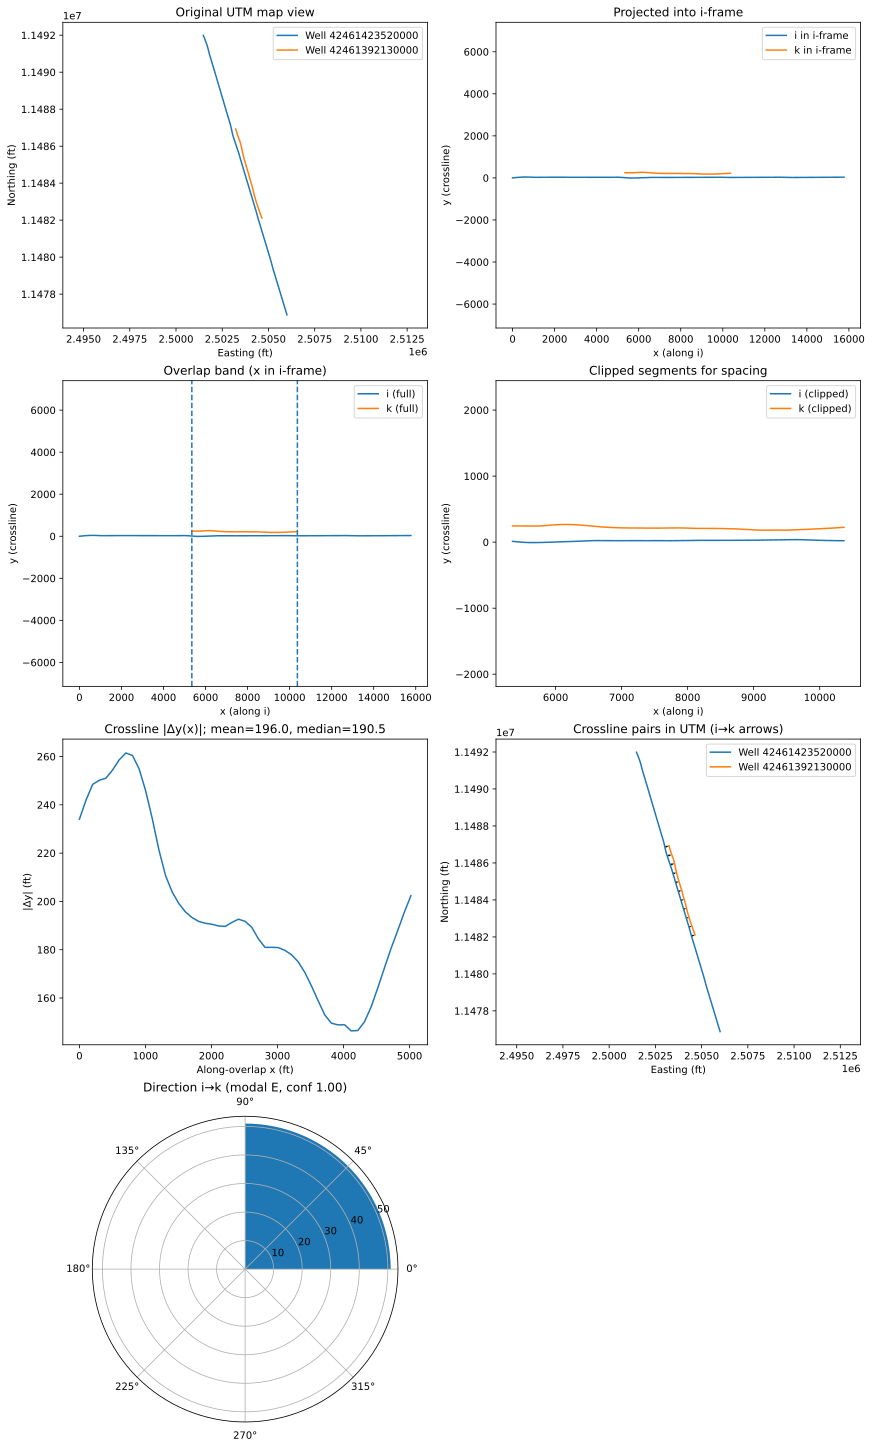

{'pair_alignment': 'parallel_like',
 'angle_deg': 0.6857618592027199,
 'paths': {},
 'overlap_x_band': (5348.420008780896, 10368.182125381605),
 'overlap_len_ft': 5019.762116600709,
 'crossline_mean_ft': 195.95208528162334,
 'crossline_median_ft': 190.54267738631782,
 'crossline_p05_ft': 148.882782585099,
 'crossline_p95_ft': 256.8081406682967,
 'crossline_n_stations': 51,
 'direction_mode_4way': 'E',
 'direction_confidence': 1.0,
 'direction_distribution': {'E': 1.0}}

In [21]:
debug_pair_spacing(
    df=df_utm_lateral,
    uwi_i="42461423520000",
    uwi_k="42461392130000",
    use_pca_axis=True,
    step_ft=100
)

In [15]:
df_header

,uwi,lease_name,well_name,well_num,operator,rsv_cat,bench,first_prod_date,comp_date,hole_direction
0,42329458280000,DAVIDSON 42B,DAVIDSON 42B 4HL,4HL,OVV,01PDP,WCB,2023-02-01,2023-02-09,H
1,42003486280000,UNIVERSITY 8-8E B,UNIVERSITY 8-8E B H 9WC,H 9WC,Piedra,01PDP,WCB,2023-12-01,2023-12-01,H
2,42329458240000,FOUR CORNERS 1423 H,FOUR CORNERS 1423 H 203H,203H,FANG,01PDP,WCB,2023-03-01,2023-03-05,H
3,42227418480000,EASTLAND BIG DADDY D,EASTLAND BIG DADDY D 1522LS,1522LS,SM,01PDP,LSS,2023-09-01,2023-09-19,H
4,42227418470000,EASTLAND BIG DADDY C,EASTLAND BIG DADDY C 1543WA,1543WA,SM,01PDP,WCA,2023-09-01,2023-09-18,H
...,...,...,...,...,...,...,...,...,...,...
25718,42165388500000,NORTH RILEY UNIT,NORTH RILEY UNIT 2340H,2340H,Sabinal,01PDP,NaN,2022-07-01,2022-06-26,H
25719,42033325730000,GOLEM 22-10,GOLEM 22-10 1AH,1AH,Surge,01PDP,WCA,2022-08-01,2022-08-04,H
25720,42033325720000,GOLEM UNIT A 23-11,GOLEM UNIT A 23-11 2AH,2AH,Surge,01PDP,WCA,2022-08-01,2022-08-06,H
25721,42115338710000,AROD 2-11-14,AROD 2-11-14 2DN,2DN,SM,01PDP,LSS,2022-07-01,2022-07-23,H
